In [1]:
!pip install tensorflow opencv-python matplotlib scikit-learn

^C
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.7 MB/s eta 0:02:12
   ---------------------------------------- 1.3/351.2 MB 2.7 MB/s eta 0:02:08
   ---------------------------------------- 1.8/351.2 MB 2.7 MB/s eta

In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

C:\Users\HP\anaconda3\envs\Neuai\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
IMG_SIZE = 160

FABRIC_LABEL = 1
NON_FABRIC_LABEL = 0

IMAGES_PER_FOLDER = 80

In [4]:
fabric_root = r"C:\Users\HP\Desktop\NeuAI Company\Fabric model\Image dataset\Dataset"

fabric_images = []
fabric_labels = []

subfolders = os.listdir(fabric_root)

print("Folders Found:", subfolders)

for folder in subfolders:

    folder_path = os.path.join(fabric_root, folder)

    if not os.path.isdir(folder_path):
        continue

    image_files = os.listdir(folder_path)

    random.shuffle(image_files)

    selected_images = image_files[:IMAGES_PER_FOLDER]

    print(f"Loading {len(selected_images)} images from {folder}")

    for file in selected_images:

        img_path = os.path.join(folder_path, file)

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            fabric_images.append(img)

            fabric_labels.append(FABRIC_LABEL)

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

print()

print("Total Fabric Images:", len(fabric_images))

Folders Found: ['Broken stitch', 'Defect-free', 'Hole', 'Horizontal', 'Lines', 'Needle mark', 'Pinched fabric', 'Stain', 'Vertical']
Loading 80 images from Broken stitch
Loading 80 images from Defect-free
Loading 80 images from Hole
Loading 80 images from Horizontal
Loading 80 images from Lines
Loading 80 images from Needle mark
Loading 80 images from Pinched fabric
Loading 80 images from Stain
Loading 80 images from Vertical

Total Fabric Images: 720


In [5]:
# LOAD CIFAR100 DATASET

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

non_fabric_images = []
non_fabric_labels = []

NON_FABRIC_COUNT = 720

print("Loading Non-Fabric Images...")

for i in range(NON_FABRIC_COUNT):

    img = x_train[i]

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    non_fabric_images.append(img)

    non_fabric_labels.append(NON_FABRIC_LABEL)

print()

print("Total Non-Fabric Images:", len(non_fabric_images))

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 124s 1us/step
Loading Non-Fabric Images...

Total Non-Fabric Images: 720


In [6]:
# COMBINE BOTH DATASETS

X = np.array(fabric_images + non_fabric_images, dtype="float32")

y = np.array(fabric_labels + non_fabric_labels)

# NORMALIZE IMAGES

X = X / 255.0

# SHUFFLE DATASET

X, y = shuffle(X, y, random_state=42)

print("Dataset Shape:", X.shape)

print("Labels Shape:", y.shape)

Dataset Shape: (1440, 160, 160, 3)
Labels Shape: (1440,)


In [7]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", len(X_train))

print("Testing Images:", len(X_test))

Training Images: 1152
Testing Images: 288


In [8]:
# CONVERT LABELS TO CATEGORICAL

y_train = to_categorical(y_train, 2)

y_test = to_categorical(y_test, 2)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

y_train Shape: (1152, 2)
y_test Shape: (288, 2)


In [9]:
# LOAD MOBILENETV2 BASE MODEL

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# FREEZE PRETRAINED WEIGHTS

base_model.trainable = False

print("Base Model Loaded Successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Base Model Loaded Successfully


In [10]:
# BUILD FINAL MODEL

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(2, activation='softmax')

])

print("Final Model Created Successfully")

Final Model Created Successfully


In [11]:
# COMPILE MODEL

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

print("Model Compiled Successfully")

Model Compiled Successfully


In [12]:
# TRAIN MODEL

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=10,

    batch_size=16

)


Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 313ms/step - accuracy: 0.8828 - loss: 0.2953 - val_accuracy: 0.9965 - val_loss: 0.0497
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.9896 - loss: 0.0471 - val_accuracy: 1.0000 - val_loss: 0.0168
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 313ms/step - accuracy: 0.9974 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 392ms/step - accuracy: 0.9983 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - accuracy: 0.9974 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 253ms/step - accuracy: 0.9983 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 292ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accu

In [13]:
# EVALUATE MODEL

loss, accuracy = model.evaluate(X_test, y_test)

print()

print(f"Test Accuracy: {accuracy * 100:.2f}%")

print(f"Test Loss: {loss:.6f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 515ms/step - accuracy: 1.0000 - loss: 8.1199e-04

Test Accuracy: 100.00%
Test Loss: 0.000812


In [14]:
# SAVE MODEL

model.save("fabric_nonfabric_classifier.keras")

print("Model Saved Successfully")


Model Saved Successfully


In [1]:
import os

size_mb = os.path.getsize("fabric_nonfabric_classifier.keras") / (1024 * 1024)

print(f"Model Size: {size_mb:.2f} MB")

Model Size: 11.16 MB


In [2]:
import os

print(os.getcwd())

C:\Users\HP\Desktop\NeuAI Company\Website


C:\Users\HP\anaconda3\envs\Neuai\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


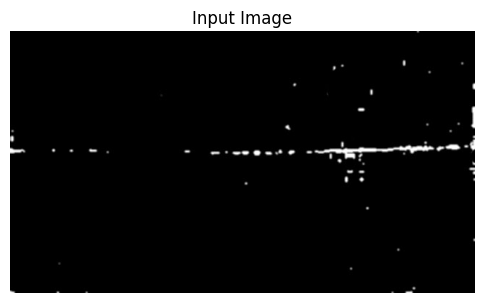

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Raw Prediction: [[2.4981166e-06 9.9999750e-01]]
✅ FABRIC IMAGE
Confidence: 100.00%


In [3]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

# LOAD MODEL

model = load_model("fabric_nonfabric_classifier.keras")

# IMAGE PATH

image_path = r"C:\Users\HP\Desktop\NeuAI Company\Fabric model\Image dataset\Dataset\Horizontal\4_processed (2).jpg"

# READ IMAGE

img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found")
    
else:

    # CONVERT BGR TO RGB

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # SHOW IMAGE

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # RESIZE IMAGE

    img_resized = cv2.resize(img_rgb, (160, 160))

    # NORMALIZE

    img_normalized = img_resized.astype("float32") / 255.0

    # ADD BATCH DIMENSION

    img_input = np.expand_dims(img_normalized, axis=0)

    # PREDICT

    prediction = model.predict(img_input)

    print("Raw Prediction:", prediction)

    class_index = np.argmax(prediction)

    confidence = np.max(prediction)

    # FINAL RESULT

    if class_index == 1:

        print(f"✅ FABRIC IMAGE")

    else:

        print(f"❌ NON-FABRIC IMAGE")

    print(f"Confidence: {confidence * 100:.2f}%")

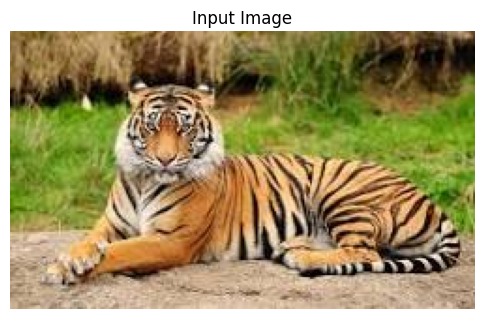

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Raw Prediction: [[0.96888924 0.03111083]]
❌ NON-FABRIC IMAGE
Confidence: 96.89%


In [5]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

# LOAD MODEL

model = load_model("fabric_nonfabric_classifier.keras")

# IMAGE PATH

image_path = r"C:\Users\HP\Desktop\NeuAI Company\Fabric model\Image dataset\animal.jfif"

# READ IMAGE

img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found")
    
else:

    # CONVERT BGR TO RGB

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # SHOW IMAGE

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # RESIZE IMAGE

    img_resized = cv2.resize(img_rgb, (160, 160))

    # NORMALIZE

    img_normalized = img_resized.astype("float32") / 255.0

    # ADD BATCH DIMENSION

    img_input = np.expand_dims(img_normalized, axis=0)

    # PREDICT

    prediction = model.predict(img_input)

    print("Raw Prediction:", prediction)

    class_index = np.argmax(prediction)

    confidence = np.max(prediction)

    # FINAL RESULT

    if class_index == 1:

        print(f"✅ FABRIC IMAGE")

    else:

        print(f"❌ NON-FABRIC IMAGE")

    print(f"Confidence: {confidence * 100:.2f}%")